In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
#import Overall Summary
overall_Summary = pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Overall Summary\B0046_Overall_Summary.csv")
overall_Summary.head()

,Cycle Pair,Battery ID,Charge_Ah,Discharge_Ah,Initial Discharge_Ah,Charge_Wh,Discharge_Wh,Charge Duration_Sec,Discharge Duration_Sec,Average_Charge_Voltage,...,Voltage Hysteresis,Max Charge Temperature,Max Discharge Temperature,Charge_Tempaerature_Rise_Rate,Discharge_Tempaerature_Rise_Rate,Coulombic_Efficiency_Ah,Energy_Efficiency_Wh,SOH,Capacity_Fade,Cycle Status
0,1,B0046,1.565530,1.574211,1.574211,6.512458,5.389009,10800.719,5613.391,4.184686,...,0.759956,9.325138,12.941526,-0.000030,0.001279,100.554468,82.749232,103.027128,NaN,Invalid : Charge Ah less than Discharge Ah
1,2,B0046,1.559614,1.557535,1.574211,6.460305,5.332786,10799.500,5553.969,4.178405,...,0.753164,12.273322,13.359691,-0.000563,0.001085,99.866729,82.546959,101.935776,1.091352,Valid
2,3,B0046,1.546832,1.544272,1.574211,6.410833,5.283612,10805.188,5506.625,4.179564,...,0.756611,11.564015,12.664053,-0.000649,0.001418,99.834503,82.416936,101.067773,0.868003,Valid
3,4,B0046,1.535317,1.531858,1.574211,6.364878,5.237118,10803.203,5461.922,4.179908,...,0.759473,12.022340,12.945408,-0.000657,0.001435,99.774756,82.281505,100.255313,0.812461,Valid
4,5,B0046,1.524705,1.521527,1.574211,6.323501,5.197334,10801.578,5423.953,4.180629,...,0.763154,12.398490,12.747556,-0.000677,0.001364,99.791555,82.190767,99.579126,0.676187,Valid


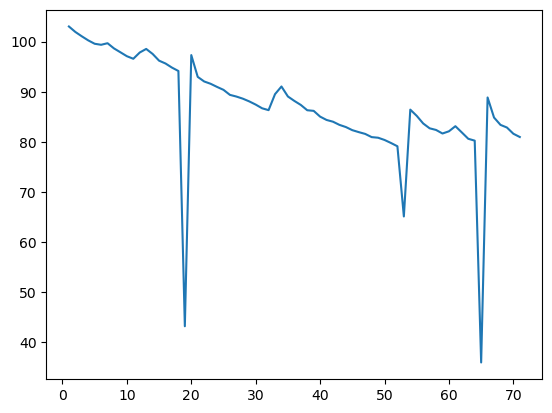

In [5]:
plt.plot(overall_Summary['Cycle Pair'], overall_Summary['SOH'])

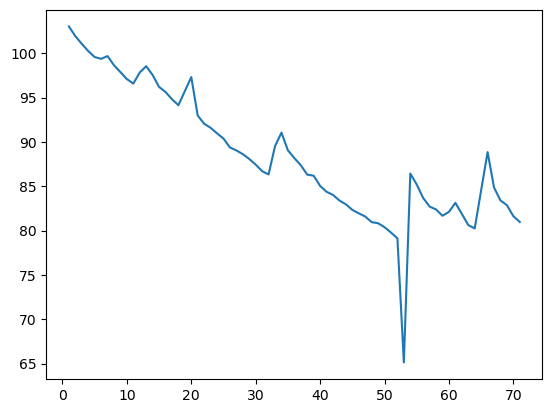

In [6]:
#Applying IQR filter to SOH data
Q1 = overall_Summary['SOH'].quantile(0.25)
Q3 = overall_Summary['SOH'].quantile(0.75)
IQR = Q3 - Q1
Lower_Limit = Q1 - 1.5 * IQR
Upper_Limit = Q3 + 1.5 * IQR

Cleaned_SOH = overall_Summary[(overall_Summary['SOH'] >= Lower_Limit) & (overall_Summary['SOH'] <= Upper_Limit)].copy()
plt.plot(Cleaned_SOH['Cycle Pair'], Cleaned_SOH['SOH'])

Train MAE: 1.476652732469241, Test MAE: 7.770154241216543
Train MSE: 7.437854464576545, Test MSE: 69.22149953209698


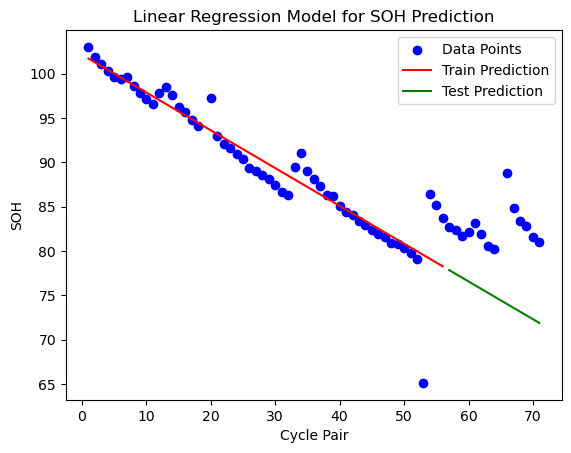

In [10]:
# Applying Linear Regression Model
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

X = Cleaned_SOH[['Cycle Pair']].values
y = Cleaned_SOH['SOH'].values

split_idx = int(0.8 * len(Cleaned_SOH))
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

model = LinearRegression()
model.fit(X_train, y_train)

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

#Evaluating Error

#1. Mean Absolute Error
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

#2. Mean Squared Error
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)

print(f"Train MAE: {train_mae}, Test MAE: {test_mae}")
print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")

# Plotting the regression line
plt.Figure(figsize=(10,6))
plt.scatter(Cleaned_SOH['Cycle Pair'], Cleaned_SOH['SOH'], color='blue', label='Data Points')
#plot traun and test predictions
plt.plot(X_train, y_train_pred, color='red', label='Train Prediction')
plt.plot(X_test, y_test_pred, color='green', label='Test Prediction')
plt.xlabel('Cycle Pair')
plt.ylabel('SOH')
plt.title('Linear Regression Model for SOH Prediction')
plt.legend()
plt.show()

